In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

from data import OptionsChain, StockHistory
from modelling import BreedenLitzenberger

In [2]:
nifty_data = StockHistory("^NSEI").get_history()

nifty_data["returns_close_std_14d"] = (
    nifty_data["log_returns_close"].rolling(window=7).std().shift(1)#.round(2)
)

In [3]:
NIFTY50 = OptionsChain(derivative="NIFTY",LOT_SIZE=65)
CE = NIFTY50.get_ce(r=0.071, expiry="2026-06-02", recompute_iv=False, min_traded_qty=100)
PE = NIFTY50.get_pe(r=0.071, expiry="2026-06-02", recompute_iv=False, min_traded_qty=100)

In [4]:
bl = BreedenLitzenberger(risk_free_rate=0.071, n_samples=20_000)

dist = bl.estimate(
    CE,
    PE,
    expiry="2026-06-02",
)

distribution_iv = bl.implied_vol_from_distribution(dist, CE)

print("Forward:", round(dist["diagnostics"]["forward"], 2))
print("Mean:", round(dist["mean_implied_expiry_level"], 2))
print("Std:", round(dist["standard_deviation"], 2))
print("Implied Volatility from distribution:", round(distribution_iv, 2))


final_day_price_samples = dist["samples"]  # numpy array with 10k sampled expiry levels

Forward: 24124.95
Mean: 24050.83
Std: 436.22
Implied Volatility from distribution: 0.12


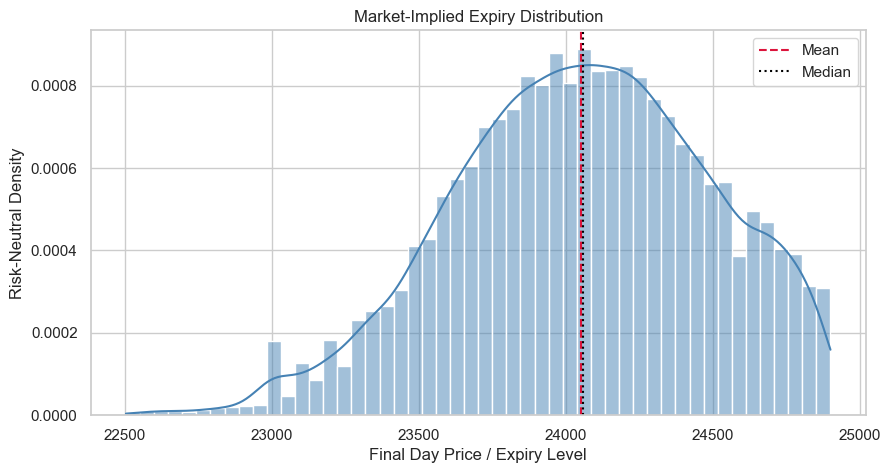

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    final_day_price_samples,
    bins=50,
    stat="density",
    kde=True,
    color="steelblue",
    edgecolor="white",
    ax=ax,
)

ax.axvline(dist["mean_implied_expiry_level"], color="crimson", linestyle="--", label="Mean")
ax.axvline(dist["quantiles"]["50%"], color="black", linestyle=":", label="Median")
ax.set_title("Market-Implied Expiry Distribution")
ax.set_xlabel("Final Day Price / Expiry Level")
ax.set_ylabel("Risk-Neutral Density")
ax.legend()
plt.show()

In [16]:
from simulations import TradeBuilder

builder = TradeBuilder(CE, PE)

trades = builder.build_trades([
    "SELL CE 24600",
    "BUY CE 24800",
])
result = builder.payoff(
    trades,
    mean=24050,
    std=440,
    n_samples=20_000,
    random_state=42,
)
pnl_dist = result["pnl"]
summary = result["summary"]

In [17]:
expected_pnl = pnl_dist.mean().round(2)
pop = (pnl_dist > 80).mean().round(4)*100

print(f"Expected P&L: {expected_pnl}")
print(f"Probability of Profit: {pop}%")

Expected P&L: 636.05
Probability of Profit: 89.96%
